# Cost Regression Model

Predicts the **actual service cost (actual_amount)** given a set of features.

**Features:** predicted_duration_mins, service_id, base_price, base_duration_hours, is_price_fixed, vehicle_age, vehicle_type, mileage

**Target:** actual_amount

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os


In [2]:
# Load data from previous pipeline step
if os.path.exists('pipeline_time_output.csv'):
    df_cost = pd.read_csv('pipeline_time_output.csv')
    print(f"Loaded {df_cost.shape[0]} rows from pipeline_time_output.csv")
else:
    print("Error: pipeline_time_output.csv not found. Please run time_regression.ipynb first.")


Loaded 3317 rows from pipeline_time_output.csv


In [3]:
# Features and Target for Cost
# ADDED: service_id (biggest missing feature — different services have very different costs)
# ADDED: mileage (worn vehicles cost more to service)
features_cost = [
    'predicted_duration_mins', 'service_id',
    'base_price', 'base_duration_hours', 'is_price_fixed',
    'vehicle_age', 'vehicle_type_encoded', 'mileage'
]
target_cost = 'actual_amount'

X_cost = df_cost[features_cost]
y_cost = df_cost[target_cost]

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(X_cost, y_cost, test_size=0.2, random_state=42)

rf_cost = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_cost.fit(X_c_train, y_c_train)

y_c_pred_train = rf_cost.predict(X_c_train)
y_c_pred_test  = rf_cost.predict(X_c_test)

# Analytics
mse_c_train = mean_squared_error(y_c_train, y_c_pred_train)
mse_c_test  = mean_squared_error(y_c_test,  y_c_pred_test)
print(f"{'Metric':<30} {'Train':>10} {'Test':>10}")
print(f"{'-'*50}")
print(f"  {'MSE':<30} {mse_c_train:>10.2f} {mse_c_test:>10.2f}")
print(f"  {'RMSE':<30} {np.sqrt(mse_c_train):>10.2f} {np.sqrt(mse_c_test):>10.2f}")
print(f"  {'MAE':<30} {mean_absolute_error(y_c_train, y_c_pred_train):>10.2f} {mean_absolute_error(y_c_test, y_c_pred_test):>10.2f}")
print(f"  {'R2_Score':<30} {r2_score(y_c_train, y_c_pred_train):>10.4f} {r2_score(y_c_test, y_c_pred_test):>10.4f}")


Metric                              Train       Test
--------------------------------------------------
  MSE                              40625.40  246857.20
  RMSE                               201.56     496.85
  MAE                                123.88     308.48
  R2_Score                           0.9933     0.9572



Feature Importances (Cost Model):
                   Feature  Importance
0  predicted_duration_mins    0.879557
2               base_price    0.040523
1               service_id    0.039818
7                  mileage    0.013920
5              vehicle_age    0.009511
4           is_price_fixed    0.008193
3      base_duration_hours    0.004381
6     vehicle_type_encoded    0.004097


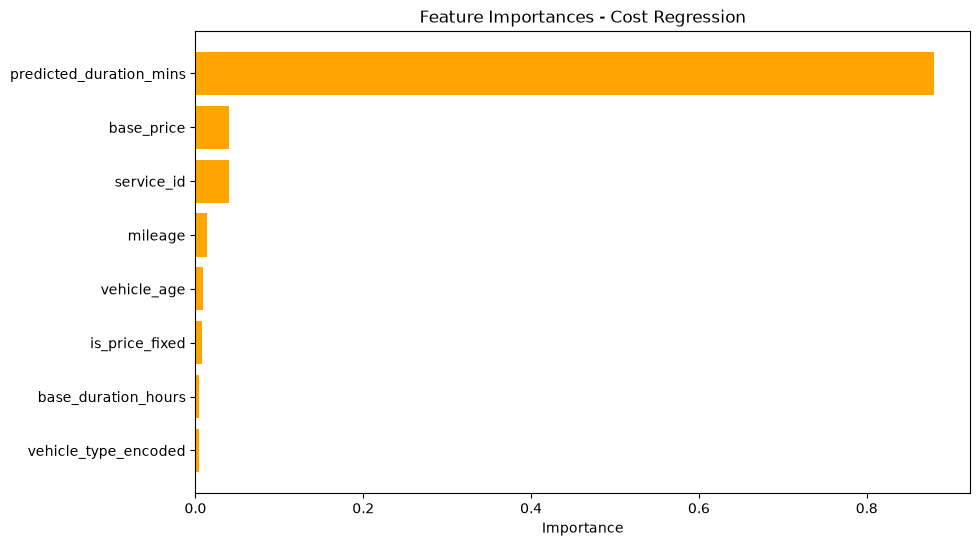

In [4]:
# Feature Importances for Cost
importances_c = rf_cost.feature_importances_
feat_imp_c = pd.DataFrame({'Feature': features_cost, 'Importance': importances_c}).sort_values(by='Importance', ascending=False)
print("\nFeature Importances (Cost Model):")
print(feat_imp_c)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_c['Feature'], feat_imp_c['Importance'], color='orange')
plt.gca().invert_yaxis()
plt.title('Feature Importances - Cost Regression')
plt.xlabel('Importance')
plt.show()


In [5]:
# Save predictions for the next step in the pipeline (Churn Model)
df_cost['predicted_amount'] = rf_cost.predict(X_cost)
df_cost.to_csv('pipeline_cost_output.csv', index=False)
print("Saved cost predictions to pipeline_cost_output.csv")


Saved cost predictions to pipeline_cost_output.csv


In [6]:
import joblib
joblib.dump(rf_cost, 'exported/cost_model.pkl')
print("Exported: cost_model.pkl")


Exported: cost_model.pkl
